# hyp3-isce3: on-demand NISAR GUNW processing

NISAR's operational GUNWs use one fixed recipe: **12-day pairs, 5×6 looks, 80 m posting**. These operational products
serves most uses but some science and operational users will want other pairs.

This is an **ASF HyP3 plugin** (`job_type: NISAR_GUNW`). You submit a pair and it is processed in the cloud
on demand. No ISCE3 install, no local compute, no RSLC downloads. It provides two things the operational
catalog cannot:

- **Pairs that were never produced.** Any two RSLCs on a track, at any temporal baseline.
- **Parameters matched to your target.** Runconfig keys can be overridden: looks, geocode posting,
  filtering, unwrapping, corrections.

Three worked examples, each changing one thing:

1. **Pairs.** A redundant network the catalog cannot supply, inverted with MintPy. Mexico City.
2. **Time.** A pair that bridges wet snow, formed from an acquisition that is not in ASF. Susanville.
3. **Resolution.** When 80 m is enough and when it is not. Kilauea and Absaroka.

Every product shown here was processed beforehand with the `hyp3-isce3` plugin, on HyP3 for section 1 and
locally for sections 2 and 3. **This notebook only reads those finished products.** It does no processing
and needs no credentials, no ISCE3 and no network. To submit jobs of your own, see `Submit_job.ipynb`.

In [1]:
import glob, json, warnings
from pathlib import Path
from datetime import datetime
import numpy as np, h5py
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pyproj import Transformer
warnings.filterwarnings('ignore')
%matplotlib inline

BASE = 'local/uwg_demo'    # demo data root; every product below is read from disk, nothing is streamed
GA = '/science/LSAR/GUNW/grids/frequencyA'

# GUNW layer -> (HDF5 group, dataset). wrapped/wcoh sit on the crossmul-look grid, so they respond to the
# multilook knob; coh/phase/cc sit on the coarser phase_unwrap grid. Never mix the two.
LAYERS = {
    'wrapped': ('wrappedInterferogram', 'wrappedInterferogram'),
    'wcoh': ('wrappedInterferogram', 'coherenceMagnitude'),
    'coh': ('unwrappedInterferogram', 'coherenceMagnitude'),
    'phase': ('unwrappedInterferogram', 'unwrappedPhase'),
    'cc': ('unwrappedInterferogram', 'connectedComponents'),
}


def read_gunw(path, aoi, layer='wrapped'):
    """Clip one GUNW layer to a lon/lat AOI -> (array, extent in UTM km)."""
    grp, ds = LAYERS[layer]
    with h5py.File(path, 'r') as f:
        g = f[f'{GA}/{grp}']
        tr = Transformer.from_crs(4326, int(g['HH/projection'].attrs['epsg_code']), always_xy=True)
        xs, ys = zip(*[tr.transform(lo, la) for lo in aoi[::2] for la in aoi[1::2]])
        x, y = g['xCoordinates'][:], g['yCoordinates'][:]
        i = np.where((x >= min(xs)) & (x <= max(xs)))[0]
        j = np.where((y >= min(ys)) & (y <= max(ys)))[0]
        arr = np.asarray(g[f'HH/{ds}'][j.min():j.max() + 1, i.min():i.max() + 1])
        x, y = x[i], y[j]

    return arr, [x.min() / 1000, x.max() / 1000, y.min() / 1000, y.max() / 1000]

---
## 1. Pairs: Mexico City subsidence, MintPy SBAS

> NASA/JPL published a NISAR subsidence map of Mexico City in April 2026, built from data spanning
> **2025-10-25 to 2026-01-17**. That is the same window as the stack below. The city sits on a compacting
> ancient lakebed drained by groundwater pumping, and parts of it drop more than 2 cm per month.
> [JPL news](https://www.jpl.nasa.gov/news/us-indian-space-mission-maps-extreme-subsidence-in-mexico-city/),
> [image release](https://www.jpl.nasa.gov/images/pia26709-us-indian-spacecraft-captures-mexico-city-subsidence/).
>
> The signal is established. What this section shows is what the processing adds.

The operational catalog holds **12-day pairs only**. A small-baseline inversion needs a **redundant
network**, with every date paired against several others, so that unwrap errors and atmosphere can be
separated from steady motion. The catalog does not contain such a network.

**24 pairs** were submitted to HyP3 and processed in the cloud: a connected network over 8 acquisitions
from 2025-10-25 to 2026-01-17, spanning 12-day to 84-day baselines. MintPy inverts them into a velocity
field and a displacement time series.

MintPy section by Mario. It runs in the `mintpy4nisar` environment. The cells below are the pipeline as
run; the result cell reads the outputs directly and does not require MintPy.

<img src="uwg_demo_assets/mexico_s2.png" width="100%">

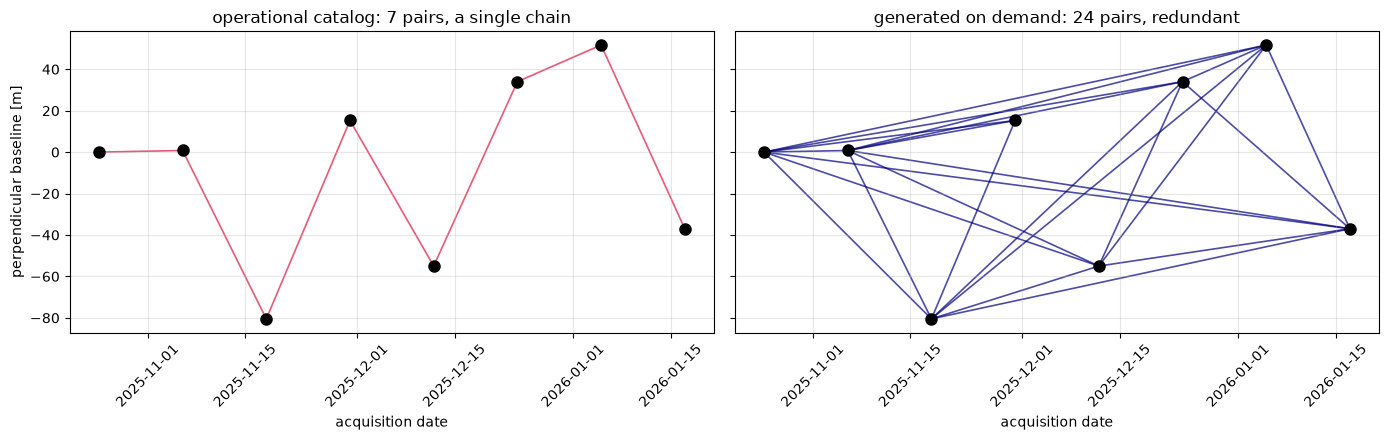

In [2]:
# --- The two networks: what the catalog offers vs what the inversion needs --------------------------
# Real perpendicular baselines and the real pair list, from the MintPy stack.
from datetime import datetime

with h5py.File(f'{BASE}/mexico_mintpy/timeseries_ramp_demErr.h5') as f:
    dates = [d.decode() for d in np.asarray(f['date'])]
    bperp = np.asarray(f['bperp'])
D = [datetime.strptime(d, '%Y%m%d') for d in dates]
idx = {d: k for k, d in enumerate(dates)}

generated = [(idx[a], idx[b]) for a, b in json.load(open(f'{BASE}/mexico_mintpy/pairs.json'))]
catalog = [(k, k + 1) for k in range(len(D) - 1)]        # operational: consecutive 12-day only

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for a, edges, title, col in [
    (ax[0], catalog, f'operational catalog: {len(catalog)} pairs, a single chain', 'crimson'),
    (ax[1], generated, f'generated on demand: {len(generated)} pairs, redundant', 'navy'),
]:
    for i, j in edges:
        a.plot([D[i], D[j]], [bperp[i], bperp[j]], '-', color=col, lw=1.2, alpha=.7, zorder=1)
    a.plot(D, bperp, 'o', color='k', ms=8, zorder=3)
    a.set(title=title, xlabel='acquisition date')
    a.grid(alpha=.3)
    a.tick_params(axis='x', rotation=45)
ax[0].set_ylabel('perpendicular baseline [m]')
plt.tight_layout(); plt.show()

view.py local/uwg_demo/mexico_mintpy/velocity.h5 velocity -m local/uwg_demo/mexico_mintpy/maskTempCoh.h5 -u cm -v -20 20 -c RdBu --noverbose


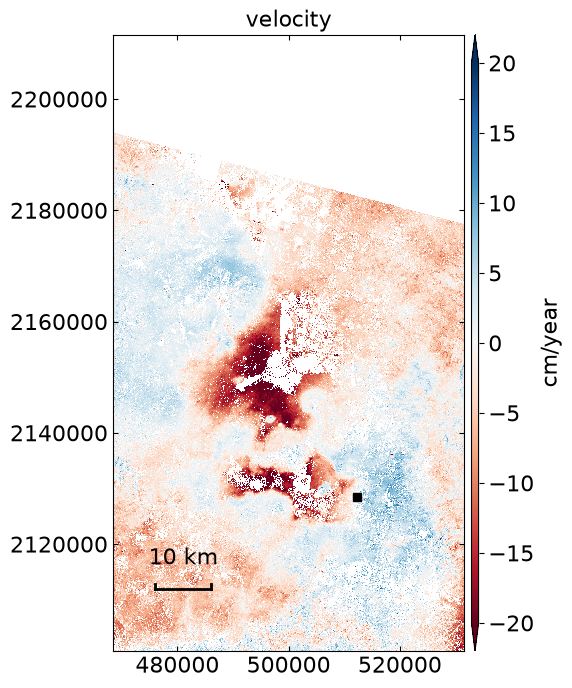

In [3]:
# --- The result: LOS velocity ----------------------------------------------------------------------
# MintPy's own viewer. -m applies its temporal-coherence mask; the reference pixel is marked by MintPy.
from mintpy.cli import view

MP = f'{BASE}/mexico_mintpy'
view.main([
    f'{MP}/velocity.h5', 'velocity',
    '-m', f'{MP}/maskTempCoh.h5',
    '-u', 'cm',                       # cm/yr
    '-v', '-20', '20',
    '-c', 'RdBu',
    '--noverbose',
])

view.py local/uwg_demo/mexico_mintpy/timeseries_ramp.h5 --ref-date 20251025 -u cm -v -7 7 -c RdBu --noverbose


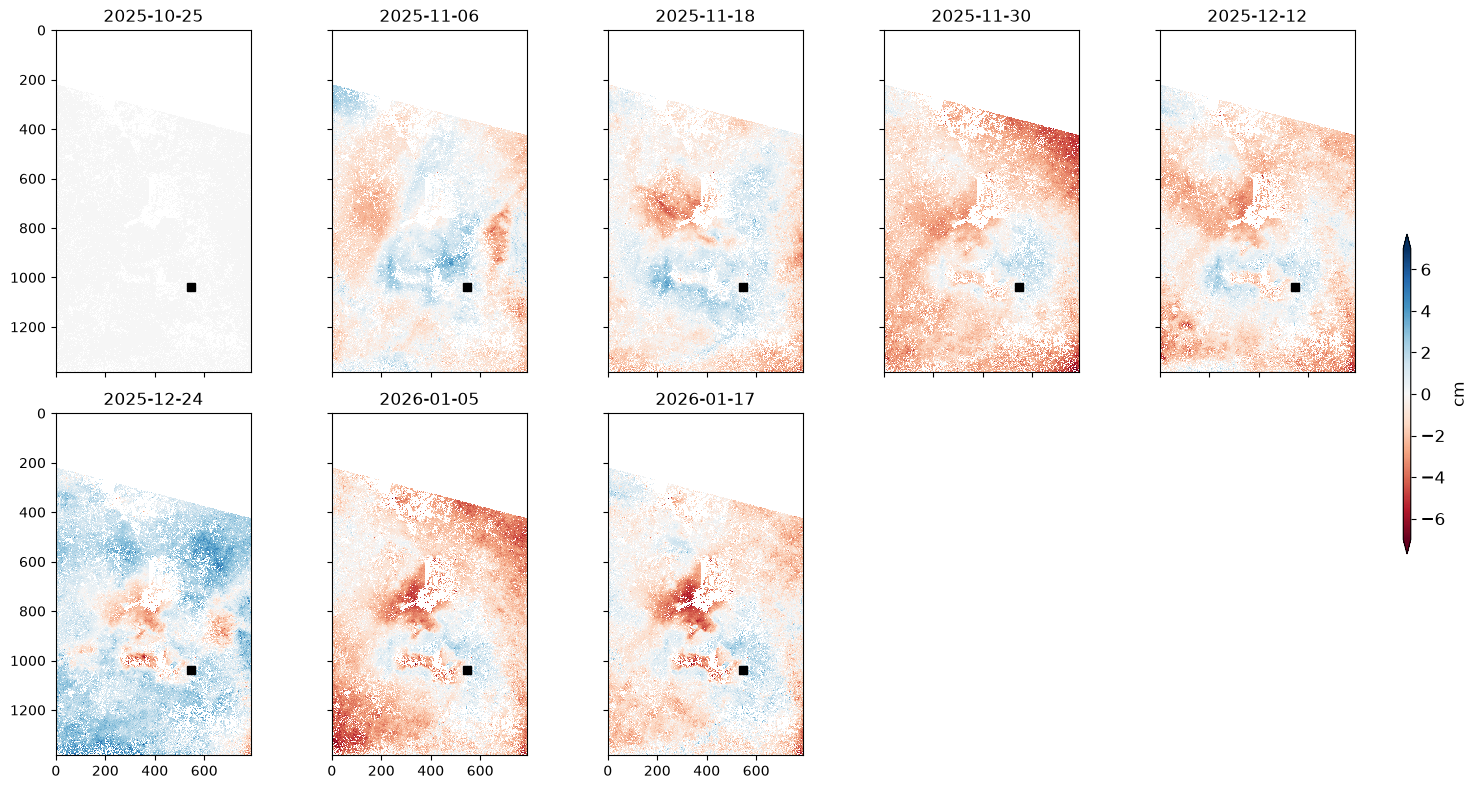

In [4]:
# --- The time series: displacement at each acquisition ----------------------------------------------
# MintPy's own viewer, static and inline. --ref-date pins the stack back to the first acquisition
# (MintPy references it to the LAST date by default, which would make every panel zero at Jan 17).
#
# For interactive browsing (click a pixel, step through dates), run this in a terminal instead --
# it opens its own window and does not fight the notebook backend:
#
#   tsview.py local/uwg_demo/mexico_mintpy/timeseries_ramp.h5 \
#       -d local/uwg_demo/mexico_mintpy/inputs/geometryGeo.h5 --ref-date 20251025 -v -7 7
from mintpy.cli import view

plt.close('all')      # MintPy names its figure "Figure 1"; the velocity view above still holds it
view.main([
    f'{BASE}/mexico_mintpy/timeseries_ramp.h5',
    '--ref-date', '20251025',
    '-u', 'cm',
    '-v', '-7', '7',
    '-c', 'RdBu',
    '--noverbose',
])

**Takeaway.** A 12-day pair measures 12 days of motion, and the operational catalog offers nothing else.
The 24-pair network above is what makes an SBAS inversion possible, and it exists only because the pairs
were generated on demand. MintPy resolves the basin at tens of cm/yr of subsidence, with temporal coherence
above 0.7 across three quarters of the scene.

The catalog supplies one pairing rule. A time series requires a network.

---
## 2. Time: skip pair over wet snow (Susanville)

Wet snow can cause significant decorrelation of interferograms. This is problematic where seasonal snow limits the ability to generate continous time series for deformation or volcano tracking. We use an ephemeral wet snow event over Susanville, CA to show how a science user could bridge a period of low coherence by processing a longer temporal baseline pair.

NAIP optical imagery over the susanville area used in the snow visualizations and insar pairs below. The red box is the AOI shared by the coherence panels below and the snow GIF.

<img src="uwg_demo_assets/susanville_naip.png" width="100%">

Ground truth below: VIIRS and SNODAS, daily from Dec 14 to Jan 31. Red marks the NISAR acquisitions.

VIIRS (optical) snow cover and SNODAS (modeled) SWE, daily. Red marks the NISAR acquisitions. The reference acquistion used on Dec 14 has no snow present, a large snow event covers the scene but melts by the 48-day pair from the reference.

<img src="uwg_demo_assets/susanville_snow.gif" width="100%">


Four pairs against one reference. Coherence on top, the snow cover that explains it below, the daily record
underneath.

    pair   secondary            snow  coherence   >0.5
  12-day    20251226         snow in       0.35    19%
  24-day    20260107            peak       0.45    41%
  36-day    20260119         melting       0.55    60%
  48-day    20260131   mostly melted       0.59    68%


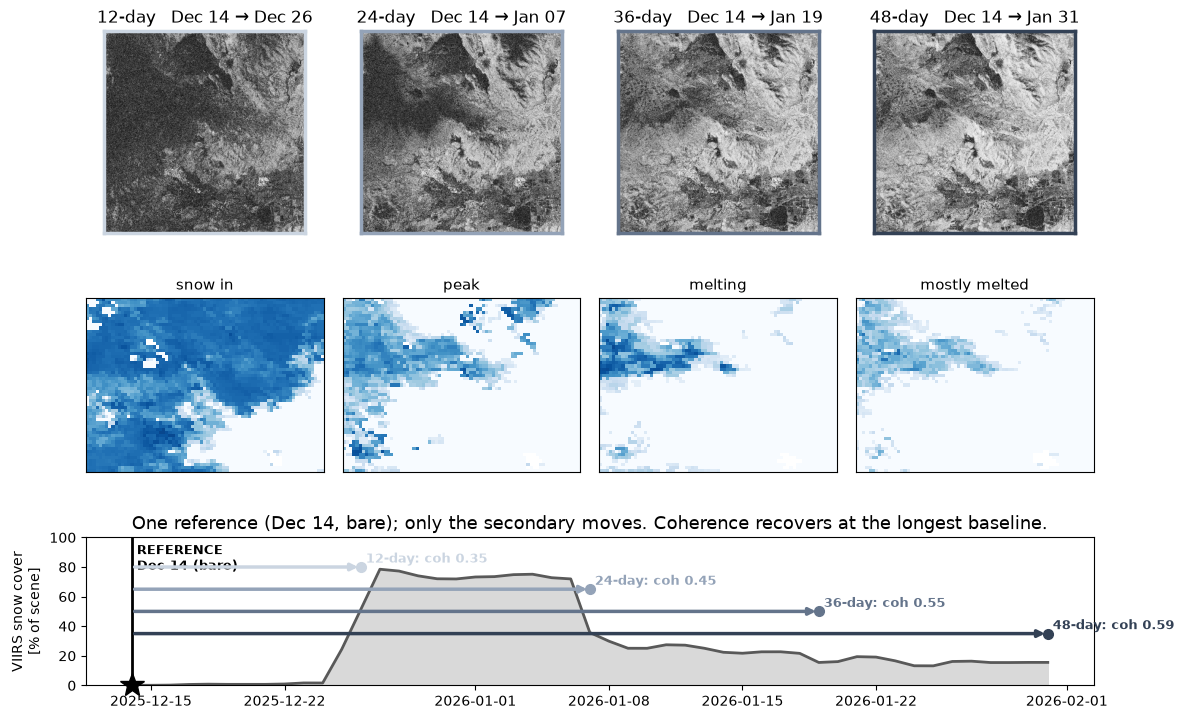

In [5]:
# Four pairs, one fixed reference: Dec 14 (bare ground) against four secondaries as the snow melts out.
SUS_AOI = (-120.75, 40.35, -120.45, 40.62)
SWEEP = [
    ('12-day', 'susan_sweep/12d',  '20251226', 'snow in'),
    ('24-day', 'susan_sweep/24d',  '20260107', 'peak'),
    ('36-day', 'susan_skip',       '20260119', 'melting'),
    ('48-day', 'susan_jan31/long', '20260131', 'mostly melted'),
]

# row 1: coherence of each pair (read live from the local GUNWs)
# row 2: VIIRS snow cover on that pair's SECONDARY -- the thing that explains row 1
# row 3: the VIIRS record, with the shared reference and each pair drawn as a span
#
# The VIIRS panels + daily series are pre-extracted (raw granules are 132 MB; this clip is 0.01 MB).
# Acquisition panels use a FORWARD median (d, d+1, d+2): Dec 26 is cloud-contaminated -- the gap-filled
# product carries stale pre-storm values there (54% cover, against ~78% on the clear days either side).
vz = np.load(f'{BASE}/clips/snow_viirs.npz')
vpanels, vpct = vz['panels'], vz['pct']
vdays = [datetime.strptime(s, '%Y-%m-%d') for s in vz['days']]
REF = datetime(2025, 12, 14)
COLS = ['#cbd5e1', '#94a3b8', '#64748b', '#334155']      # light -> dark as the baseline grows

fig = plt.figure(figsize=(13, 8.5))
gs = fig.add_gridspec(3, 4, height_ratios=[1.5, 1.5, 1.1], hspace=0.28, wspace=0.08)

means = []
print(f"{'pair':>8} {'secondary':>11} {'snow':>15} {'coherence':>10} {'>0.5':>6}")
for k, (lbl, d, sec, state) in enumerate(SWEEP):
    coh, _ = read_gunw(glob.glob(f'{BASE}/{d}/NISAR_L2_OD_GUNW_*.h5')[0], SUS_AOI, 'coh')
    frac = float(np.mean(coh[np.isfinite(coh)] > 0.5) * 100)
    means.append(float(np.nanmean(coh)))
    print(f'{lbl:>8} {sec:>11} {state:>15} {means[-1]:>10.2f} {frac:>5.0f}%')

    a0 = fig.add_subplot(gs[0, k])
    a0.imshow(coh, cmap='gray', vmin=0, vmax=1, origin='upper')
    a0.set_title(f'{lbl}   Dec 14 → {datetime.strptime(sec, "%Y%m%d"):%b %d}', fontsize=12)
    a0.set_xticks([]); a0.set_yticks([])
    for sp in a0.spines.values():
        sp.set_edgecolor(COLS[k]); sp.set_linewidth(2.5)

    a1 = fig.add_subplot(gs[1, k])
    a1.imshow(vpanels[k], cmap='Blues', vmin=0, vmax=100, origin='upper')
    a1.set_title(state, fontsize=11)
    a1.set_xticks([]); a1.set_yticks([])

axt = fig.add_subplot(gs[2, :])
axt.plot(vdays, vpct, '-', color='0.35', lw=2, zorder=2)
axt.fill_between(vdays, vpct, color='0.85', zorder=1)
axt.axvline(REF, color='k', lw=2, zorder=3)
axt.plot(REF, 0, marker='*', ms=18, color='k', zorder=4, clip_on=False)
axt.text(REF, 96, ' REFERENCE\n Dec 14 (bare)', fontsize=9, va='top', weight='bold')
for k, (lbl, _, sec, _) in enumerate(SWEEP):
    s = datetime.strptime(sec, '%Y%m%d')
    y = 80 - 15 * k                                       # stack the spans so they do not overlap
    axt.annotate('', xy=(s, y), xytext=(REF, y), arrowprops=dict(arrowstyle='-|>', color=COLS[k], lw=2.5))
    axt.plot(s, y, 'o', color=COLS[k], ms=7)
    axt.text(s, y + 3, f' {lbl}: coh {means[k]:.2f}', color=COLS[k], fontsize=9, weight='bold')
axt.set_ylabel('VIIRS snow cover\n[% of scene]')
axt.set_ylim(0, 100)
axt.set_title('One reference (Dec 14, bare); only the secondary moves. Coherence recovers at the longest baseline.',
              fontsize=13)
plt.show()

**Takeaway.** Coherence against the bare reference tracks the snow cover on the secondary: **0.35** with the
snow in, **0.59** once it has mostly melted, at four times the baseline.

Temporal decorrelation can only cost coherence as time passes. It cannot return coherence. So the baseline
is not what drives this result. The surface is: it returned to the state the reference saw. **Coherence
follows surface change, not elapsed time**, and a longer pair can be the coherent one.

None of these four pairs is in the operational catalog, and the 2026-01-31 acquisition is not in the RSLC
archive at all. They must be formed rather than selected.

---
## 3. Looks and posting: how fine does the product need to be?

The operational GUNW is fixed at **5×6 looks, 80 m posting**. That recipe is tuned for land-surface
deformation, and for deformation it is sufficient: the signal is broad, so 80 m resolves it.

Whether it is sufficient for a given target depends on the scale that target varies over. Two cases follow:

1. **Kilauea.** Volcanic deformation. The looks are swept at fixed 20 m posting to show what the knob does.
2. **Absaroka.** Dry snow. The same recipe applied to a signal that varies at the scale of drifts and gullies.

| Knob | Override key | Effect |
|---|---|---|
| Multilook | `processing.crossmul.range_looks` / `azimuth_looks` | resolution against speckle |
| Posting | `processing.geocode.output_posting.A.x_posting` / `y_posting` | output pixel spacing |

NAIP optical image of summit of Kileau. **Solid red** marks the AOI of the panels below. **Dashed red**
marks the 2 km zoom inset. The dark pit at the centre is Halemaumau, an active lava lake. It resurfaces
between passes, holds no stable scatterers, and stays decorrelated at every look level.

<img src="uwg_demo_assets/kilauea_naip.png" width="100%">

 looks  mean coh
   2x2      0.71
   5x6      0.66
 10x12      0.65
 20x24      0.65


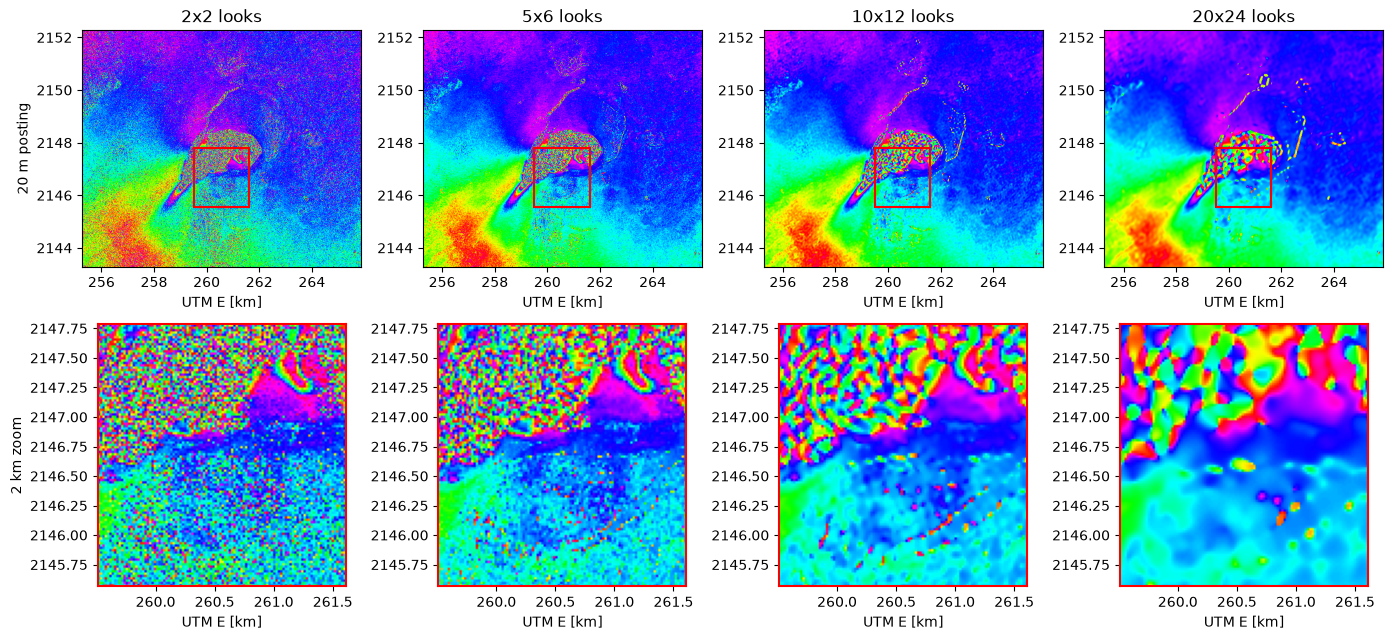

In [6]:
# Multilook sweep: same pair, posting pinned at 20 m, only the looks change.
AOI = (-155.33, 19.37, -155.23, 19.45)    # Kilauea summit / Halemaumau
ZOOM = (-155.29, 19.39, -155.27, 19.41)   # 2 km box (red) where per-pixel speckle is resolvable
LOOKS = ['2x2', '5x6', '10x12', '20x24']  # 5x6 = the operational look count


def gunw(look):
    d = f'{BASE}/kilauea_run' if look == '2x2' else f'{BASE}/kilauea_looks/{look}'
    return glob.glob(f'{d}/NISAR_L2_OD_GUNW_*.h5')[0]


fig, ax = plt.subplots(2, 4, figsize=(14, 6.5))
print(f"{'looks':>6} {'mean coh':>9}")
for k, look in enumerate(LOOKS):
    w, ext = read_gunw(gunw(look), AOI, 'wrapped')     # crossmul-look grid: responds to the knob
    wz, ez = read_gunw(gunw(look), ZOOM, 'wrapped')
    coh, _ = read_gunw(gunw(look), AOI, 'wcoh')        # coherence on that same grid (printed, not plotted)

    ax[0, k].imshow(np.angle(w), cmap='hsv', extent=ext, origin='upper', vmin=-np.pi, vmax=np.pi)
    ax[0, k].add_patch(Rectangle((ez[0], ez[2]), ez[1] - ez[0], ez[3] - ez[2], ec='red', fc='none', lw=1.5))
    ax[0, k].set_title(f'{look} looks')

    ax[1, k].imshow(np.angle(wz), cmap='hsv', extent=ez, origin='upper', vmin=-np.pi, vmax=np.pi)
    for sp in ax[1, k].spines.values():
        sp.set(edgecolor='red', linewidth=1.5)

    print(f'{look:>6} {np.nanmean(coh):>9.2f}')

ax[0, 0].set_ylabel('20 m posting')
ax[1, 0].set_ylabel('2 km zoom')
for a in ax.ravel():
    a.set_xlabel('UTM E [km]')
plt.tight_layout(); plt.show()

**Takeaway: deformation is sufficiently resolved at 80 m.** Multilooking trades resolution against speckle.
At fixed 20 m posting, 2×2 through 20×24 looks smooths the speckle away and averages out fine structure with
it. Mean coherence falls from 0.71 to 0.65, which is an estimator effect rather than lost signal: few-look
coherence is biased high and is not comparable across look counts.

Nothing in this scene requires the knob. Volcanic and tectonic deformation is broad, and the operational
5×6 / 80 m recipe already resolves it. That is what the recipe was tuned for.

The picture changes when the signal is not broad.

---
### Dry snow: where 80 m is not sufficient

Dry snow adds a phase delay that tracks the snowpack, and the snowpack is **not broad**. Wind redistributes
it at the scale of ridges, gullies and lee slopes, which is tens of metres rather than hundreds. A 5×6-look,
80 m pixel averages scoured ridge and loaded lee together.

NAIP optical imagery over the southern Absaroka mountains, Montana. The red box is the reprocessed area. The gullies and lee slopes are the scale the snow
varies at, and a single 80 m pixel spans several of them.

<img src="uwg_demo_assets/absaroka_s_naip.png" width="100%">

One pair over the **Absaroka Range**, 157D, 2025-12-27 to 2026-01-08. Same ground, three views of the same
snow, draped on 10 m terrain with every pixel shown:

- **Operational, 80 m.** The GUNW as delivered. Structure is quantised into blocks.
- **Reprocessed, 20 m.** 2×2 looks. Deposition banks into the lee bowls and scour runs along the ridge lines.
- **SNODAS, 1 km.** The model gains 36 to 81 mm SWE over the pair and captures the broad accumulation, but
  the whole AOI is 6 by 8 cells, so the redistribution is not representable at that scale.

The InSAR panels show phase rather than SWE, which is what the data supports directly. The regional ramp is
removed, and the colour scales are separate because no calibration between them is claimed.

**Only the looks can fix this.** Crossmul multilooks in radar coordinates before geocoding, so the
operational product's resolution is fixed at 5×6 looks regardless of the grid it is resampled onto. The GUNW
ships a 20 m wrapped layer, and that layer is still 5×6-look data. Finer resolution requires returning to
the RSLCs, which is the job this repo submits.

<img src="uwg_demo_assets/absaroka_s_drape.png" width="100%">

**Takeaway: the recipe follows the signal.** The operational 5×6 / 80 m GUNW is tuned for land-surface
deformation, and for deformation it is sufficient, as Kilauea shows above. Dry snow varies at drift scale.
At 80 m the wind-loaded structure is quantised into blocks. Reprocessed at 2×2 looks and 20 m posting, the
same pair resolves deposition banked in the lee bowls and scour along the ridge lines.

The argument applies to any signal that varies faster than the operational grid. Decide what scale the
science varies over, then set the looks and posting to match.

---
### Summary

| What the catalog gives you | What you can do instead | Result |
|---|---|---|
| 12-day pairs, a single chain | a redundant 24-pair network, 12 to 84 day, inverted with MintPy | Section 1, Mexico City: SBAS velocity, peak −59 cm/yr |
| a pair that lands on wet snow | a fixed-reference sweep; form the pair you need | Section 2, Susanville: coherence 0.35 to 0.59 |
| 5×6 looks, 80 m posting | looks and posting matched to your signal | Section 3: sufficient for deformation at Kilauea, insufficient for snow at Absaroka |

The recipe is tuned for land-surface deformation, and for deformation it holds up. The catalog's pairing
rule is the harder limit. A time-series inversion needs a network, a decorrelated date needs bridging, and
neither can be selected from what already exists.

Also overridable and not shown here: Goldstein filtering, unwrap settings, ionosphere and troposphere
corrections, and the coregistration-refinement chain (`dense_offsets`, `rubbersheet`, `fine_resample`).
Disabling the last is about 22% faster at a coherence cost of 0.003.